note : 
 I wrote all the code myself.
 I used Microsoft Copilot to help explain some ideas
 and to organize formatting (spacing , line order , Functions), and help me structure the report...
 All logic and tasks come directly from the ML Foundations course slides.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("insurance.csv")
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")
    df["charges"] = pd.to_numeric(df["charges"], errors="coerce")

    df = df.drop_duplicates()

    upper = df["charges"].quantile(0.99)
    df["charges"] = df["charges"].clip(upper=upper)

    return df
df_cleaned = clean_data(df)


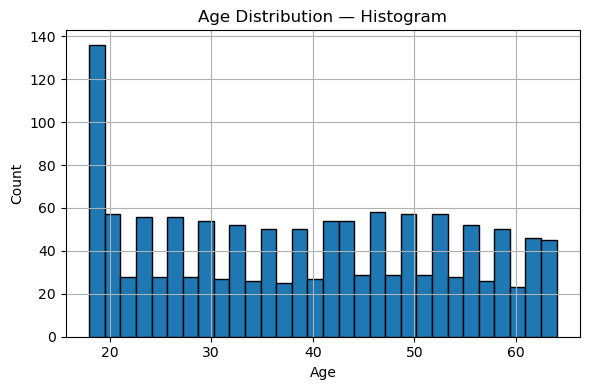

In [102]:


plt.figure(figsize=(6, 4))
df_cleaned["age"].hist(bins=30, edgecolor="black")
plt.title("Age Distribution — Histogram")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


The age distribution is unimodal, with a clear peak at 18, meaning this age appears most frequently in the dataset. After that, ages from 20 to 60 are spread out more evenly. All values fall within a normal range, so there are no outliers in the age feature.


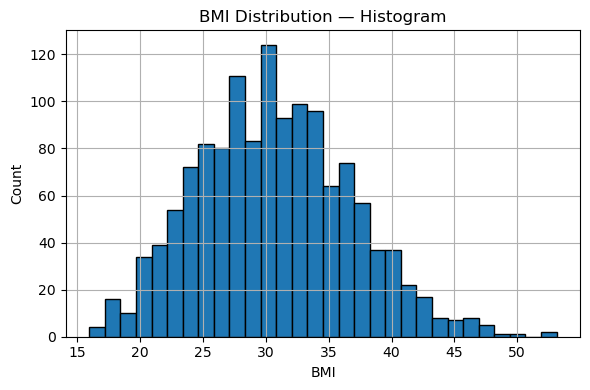

In [58]:
plt.figure(figsize=(6, 4))
df_cleaned["bmi"].hist(bins=30, edgecolor="black")
plt.title("BMI Distribution — Histogram")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


The BMI distribution is right‑skewed, with most values concentrated between 25 and 35. The left side of the histogram appears higher because these BMI values are the most common in the dataset. A few higher values appear above 50, but they are rare rather than outliers, and they still fall within a realistic BMI range.


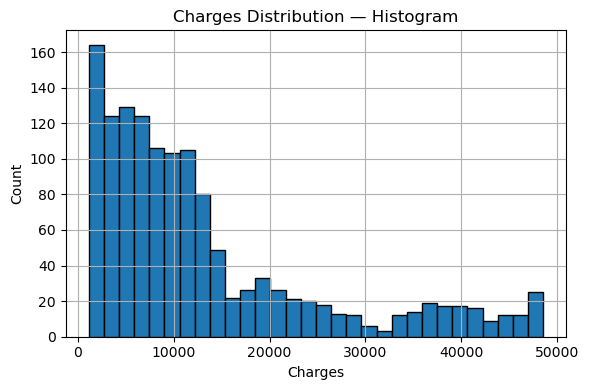

In [59]:
plt.figure(figsize=(6, 4))
df_cleaned["charges"].hist(bins=30, edgecolor="black")
plt.title("Charges Distribution — Histogram")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


The charges distribution is right‑skewed, with most individuals paying lower medical costs. Some very high charges appear on the right side, but these values are rare rather than true outliers, as they represent realistic high‑cost medical cases.


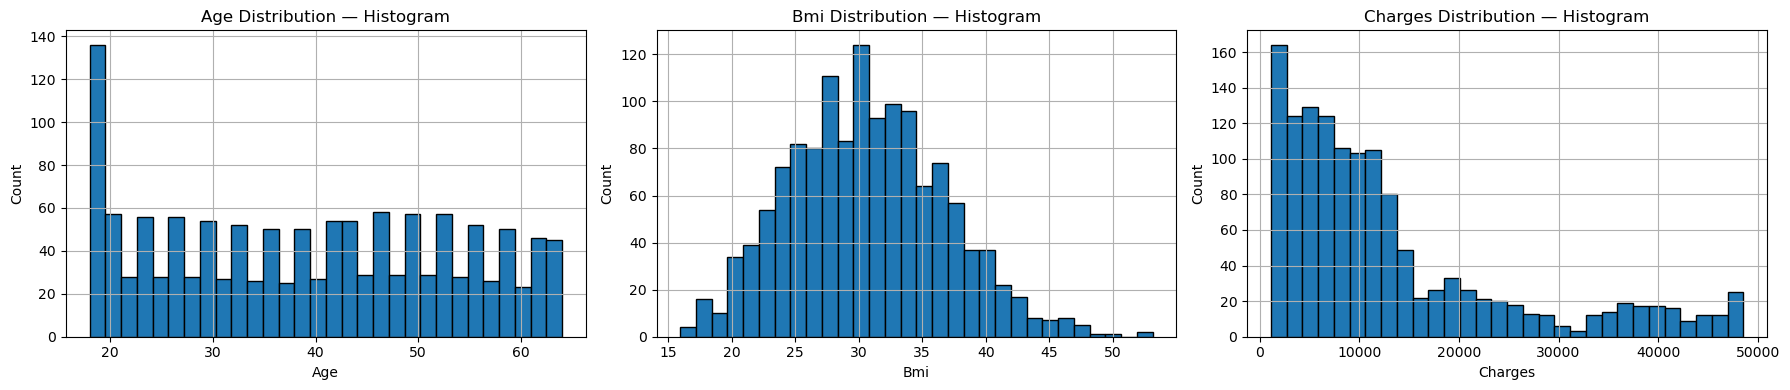

In [103]:
numeric_cols = ["age", "bmi", "charges"]

# Some AI assistance was used in this idea.
plt.figure(figsize=(18, 4))

for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i+1)
    df_cleaned[col].hist(bins=30, edgecolor="black")
    plt.title(f"{col.capitalize()} Distribution — Histogram")
    plt.xlabel(col.capitalize())
    plt.ylabel("Count")
    plt.tight_layout()

plt.show()


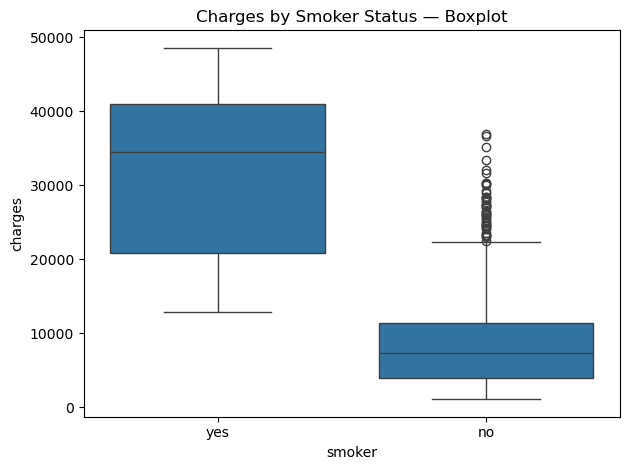

In [61]:
sns.boxplot(data=df_cleaned, x="smoker", y="charges")
plt.title("Charges by Smoker Status — Boxplot")
plt.tight_layout()
plt.show()


The boxplot illustrates the difference in medical charges between smokers and non‑smokers. Smokers (“yes”) show significantly higher charges, with a higher median and a much wider spread, indicating large variability in medical costs for this group.
Non‑smokers (“no”) have lower charges and a narrower distribution, meaning most individuals in this group pay similar and relatively low amounts. However, several outliers appear above the upper whisker. These outliers are expected, because the non‑smoker distribution is very tight — even moderately high values are flagged as outliers within this subgroup, even after applying capping at the 99th percentile.
Overall, the plot clearly shows that smoking is a strong driver of higher medical charges, while the presence of outliers in the non‑smoker group reflects the shape of the distribution rather than a data‑cleaning issue.


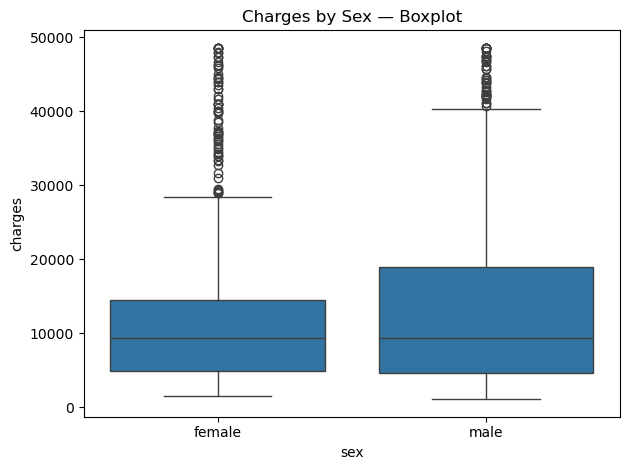

In [62]:
sns.boxplot(data=df_cleaned, x="sex", y="charges")
plt.title("Charges by Sex — Boxplot")
plt.tight_layout()
plt.show()


The boxplot compares medical charges between females and males. Overall, the two groups show very similar distributions, indicating that sex does not strongly influence insurance charges.
The median charge for males is slightly lower than that of females, as shown by the lower position of the median line inside the male box. However, this difference is small and not statistically meaningful, since both groups have nearly identical interquartile ranges (IQR) and overlapping whiskers. This means that the typical range of charges is almost the same for both sexes.
Both groups also contain several outliers, which is expected in medical‑cost data due to naturally high‑cost cases. These outliers remain visible even after applying capping at the 99th percentile, and they do not indicate a data‑cleaning issue.
Overall, the plot suggests that sex is not a major predictor of medical charges, especially when compared to stronger factors such as smoking status.


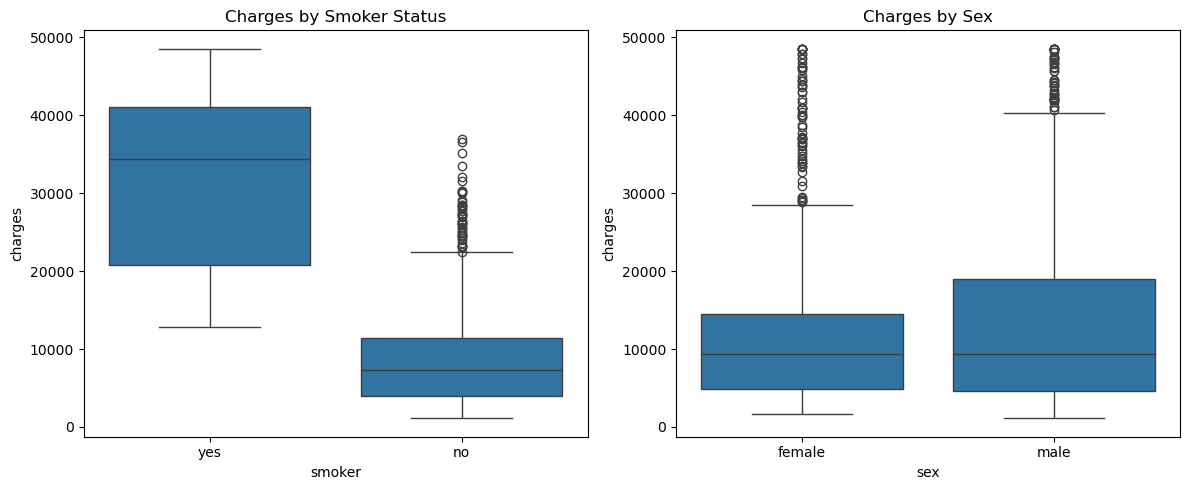

In [104]:

plt.figure(figsize=(12, 5))

# 1) Charges by Smoker
plt.subplot(1, 2, 1)
sns.boxplot(data=df_cleaned, x="smoker", y="charges")
plt.title("Charges by Smoker Status")

# 2) Charges by Sex
plt.subplot(1, 2, 2)
sns.boxplot(data=df_cleaned, x="sex", y="charges")
plt.title("Charges by Sex")

plt.tight_layout()
plt.show()


In [64]:
def Engineer_Transform_Features(df_clean):
    df = df_clean.copy()

    df = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True)

    df["bmi_age_interaction"] = df["bmi"] * df["age"]
    df["bmi_per_age"] = df["bmi"] / df["age"].replace({0: np.nan})

    df["charges_log1p"] = np.log1p(df["charges"])

    bin_edges = [17, 30, 50, 100]
    labels = ["Young", "Middle", "Senior"]
    df["age_bins_width"] = pd.cut(df["age"], bins=bin_edges, labels=labels, right=False)

    df_numeric = df.select_dtypes(include=[np.number])
    corr_matrix = df_numeric.corr().abs()

    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
    df_numeric = df_numeric.drop(columns=to_drop)


    return df
df_transformed = Engineer_Transform_Features(df_cleaned)



In [65]:
corr_matrix = df_transformed[[
    "charges",
    "charges_log1p",
    "age",
    "bmi",
    "children",
    "bmi_age_interaction",
    "bmi_per_age",
    "sex_male",
    "smoker_yes",
    "region_northwest",
    "region_southeast",
    "region_southwest"
]].corr()

print(corr_matrix)


                      charges  charges_log1p       age       bmi  children  \
charges              1.000000       0.895937  0.300596  0.196643  0.069540   
charges_log1p        0.895937       1.000000  0.527478  0.131997  0.160918   
age                  0.300596       0.527478  1.000000  0.109344  0.041536   
bmi                  0.196643       0.131997  0.109344  1.000000  0.012755   
children             0.069540       0.160918  0.041536  0.012755  1.000000   
bmi_age_interaction  0.334839       0.492032  0.879702  0.539920  0.042397   
bmi_per_age         -0.160530      -0.418985 -0.820110  0.368446 -0.118307   
sex_male             0.058811       0.007017 -0.019814  0.046397  0.017848   
smoker_yes           0.790154       0.665074 -0.025587  0.003746  0.007331   
region_northwest    -0.039529      -0.015537  0.001495 -0.136138  0.026044   
region_southeast     0.072749       0.014582 -0.012311  0.270057 -0.023492   
region_southwest    -0.042915      -0.042250  0.009415 -0.006211

In [101]:
target = "charges_log1p"

df_corr = df_transformed.select_dtypes(include=[np.number])

top10 = (
    df_corr.corr()[target]
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index
)

top10
# Some AI assistance was used in this idea.

Index(['charges_log1p', 'charges', 'age', 'bmi_age_interaction', 'bmi_per_age',
       'children', 'bmi'],
      dtype='object')

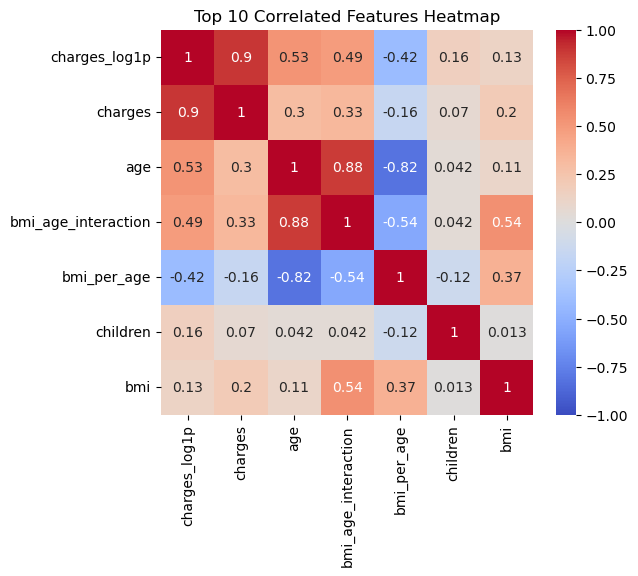

In [67]:
plt.figure(figsize=(6, 5))
sns.heatmap(df_corr[top10].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Top 10 Correlated Features Heatmap")
plt.show()


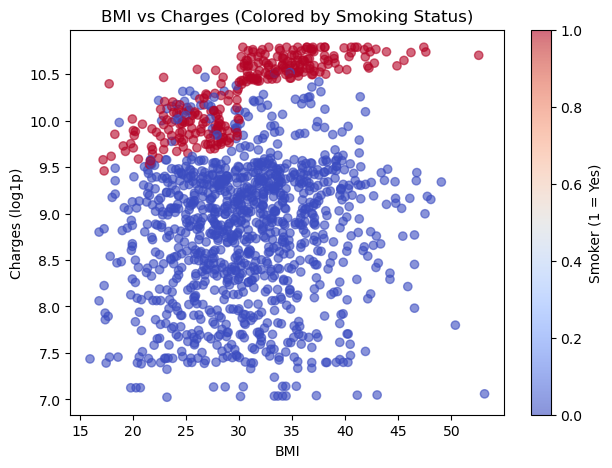

In [68]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df_transformed["bmi"],
    df_transformed["charges_log1p"],
    c=df_transformed["smoker_yes"],
    cmap="coolwarm",
    alpha=0.6
)

plt.title("BMI vs Charges (Colored by Smoking Status)")
plt.xlabel("BMI")
plt.ylabel("Charges (log1p)")
plt.colorbar(label="Smoker (1 = Yes)")
plt.show()
#- كل ما زاد BMI → تزيد التكاليف


In [69]:
df_transformed.groupby("age_bins_width")["charges_log1p"].mean()

C:\Users\PC\AppData\Local\Temp\ipykernel_29188\1335604388.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_transformed.groupby("age_bins_width")["charges_log1p"].mean()


age_bins_width
Young     8.478024
Middle    9.190663
Senior    9.642956
Name: charges_log1p, dtype: float64

A groupby summary of mean medical charges across age categories shows a clear upward trend. Seniors have the highest average charges, followed by middle-aged individuals, while young adults incur the lowest costs. This pattern aligns with expected increases in healthcare utilization with age.


**Histogram Distributions — Age, BMI, Charges**  
**Insight:**  
The age distribution is unimodal with a clear peak at age 18, indicating that this age appears most frequently in the dataset. Ages from 20 to 60 are more evenly spread, and all values fall within a realistic range, meaning no outliers are present in the age feature. The BMI distribution is right‑skewed, with most values concentrated between 25 and 35. A few higher BMI values appear above 50, but they are rare rather than true outliers and still fall within a plausible human range. The charges distribution is also right‑skewed, showing that most individuals incur relatively low medical costs, while a small number of high‑cost cases appear on the right tail. These high values are realistic and represent expensive medical events rather than data errors.

**Boxplot — Charges by Smoker Status**  
**Insight:**  
The boxplot shows a strong difference in medical charges between smokers and non‑smokers. Smokers have a much higher median charge and a wider spread, indicating large variability in medical expenses within this group. Non‑smokers have lower and more consistent charges, reflected by a narrower interquartile range. Several outliers appear among non‑smokers, but these are expected because their distribution is tight—so even moderately high values are flagged as outliers. Overall, the visualization clearly demonstrates that smoking is a major driver of higher medical charges.

**Boxplot — Charges by Sex**  
**Insight:**  
The comparison between males and females shows that sex does not significantly influence medical charges. Both groups have nearly identical distributions, with similar medians, interquartile ranges, and whiskers. Although females show a slightly higher median, the difference is small and not meaningful. Outliers appear in both groups, which is normal for medical‑cost data due to naturally high‑cost cases. Overall, sex is not a strong predictor of medical charges compared to other factors such as smoking.

**Correlation Heatmap — Top Correlated Features**  
**Insight:**  
The correlation heatmap highlights the strongest relationships with medical charges. Age and the BMI–age interaction show strong positive correlations, indicating that older individuals and those with higher combined BMI and age tend to incur higher costs. The BMI‑per‑age ratio shows a moderate negative correlation, suggesting that disproportionate BMI relative to age may signal health risks. BMI and children have weaker correlations, meaning they contribute less predictive power individually. The heatmap helps identify which features are most influential for modeling medical expenses.

**Scatter Plot — BMI vs Charges (Colored by Smoking Status)**  
**Insight:**  
The scatter plot reveals a clear separation between smokers and non‑smokers. Smokers consistently appear at higher charge levels regardless of BMI, forming a distinct cluster in the upper region of the plot. This indicates that smoking is a major cost driver independent of body mass. Non‑smokers show a more gradual and dispersed pattern, suggesting that BMI alone does not strongly predict charges unless combined with other risk factors. The visualization captures non‑linear patterns that correlation alone cannot reveal.

**Groupby Summary — Mean Charges by Age Category**  
**Insight:**  
The groupby analysis shows a clear upward trend in average medical charges across age categories. Seniors have the highest mean charges, followed by middle‑aged individuals, while young adults incur the lowest costs. This pattern aligns with typical healthcare utilization, where older individuals require more frequent and costly medical interventions. The result confirms age as a key demographic factor influencing medical charges.

In [70]:
y = df_transformed["charges"].values

meann=np.mean(y)
stdd=np.std(y)
varr=np.var(y)
print( meann,"...",stdd,"...",varr)
# حساب الاحصائيات الاساسية 

13229.380903755422 ... 11937.109835237112 ... 142494591.2185146


In [71]:
x = df_transformed["bmi"].values

mean_x = np.mean(x)
std_x = np.std(x)

z_manual = (x - mean_x) / std_x
print(z_manual)
#  Z‑score 
#عشان نوحّد المقياس (Standardization)


[-0.45315959  0.50942165  0.3831546  ...  1.01448983 -0.79752426
 -0.26129928]


In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
z_sklearn = scaler.fit_transform(df_transformed[["bmi"]]) 
print(z_sklearn)
#  same values

[[-0.45315959]
 [ 0.50942165]
 [ 0.3831546 ]
 ...
 [ 1.01448983]
 [-0.79752426]
 [-0.26129928]]


In [81]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

a = np.array([28, 36.4, 1])   
b = np.array([50, 46.09, 1])    

cos_value = cosine_similarity(a, b)
cos_value
# يقيس مدى تشابه صفين

np.float64(0.9855019329468704)

In [83]:
threshold = 20000

event_B = df_transformed["smoker_yes"] == True
event_A_and_B = (df_transformed["charges"] > threshold) & event_B

probability = event_A_and_B.sum() / event_B.sum()
probability
#77.37% smoker
# Some AI assistance was used in this idea.
#حساب احتمال أن تكون التكاليف عالية (أكثر من 20,000) بشرط أن الشخص مدخن.
# يعطي معلومة قوية جدًا عن تأثير التدخين على التكاليف.





np.float64(0.7737226277372263)

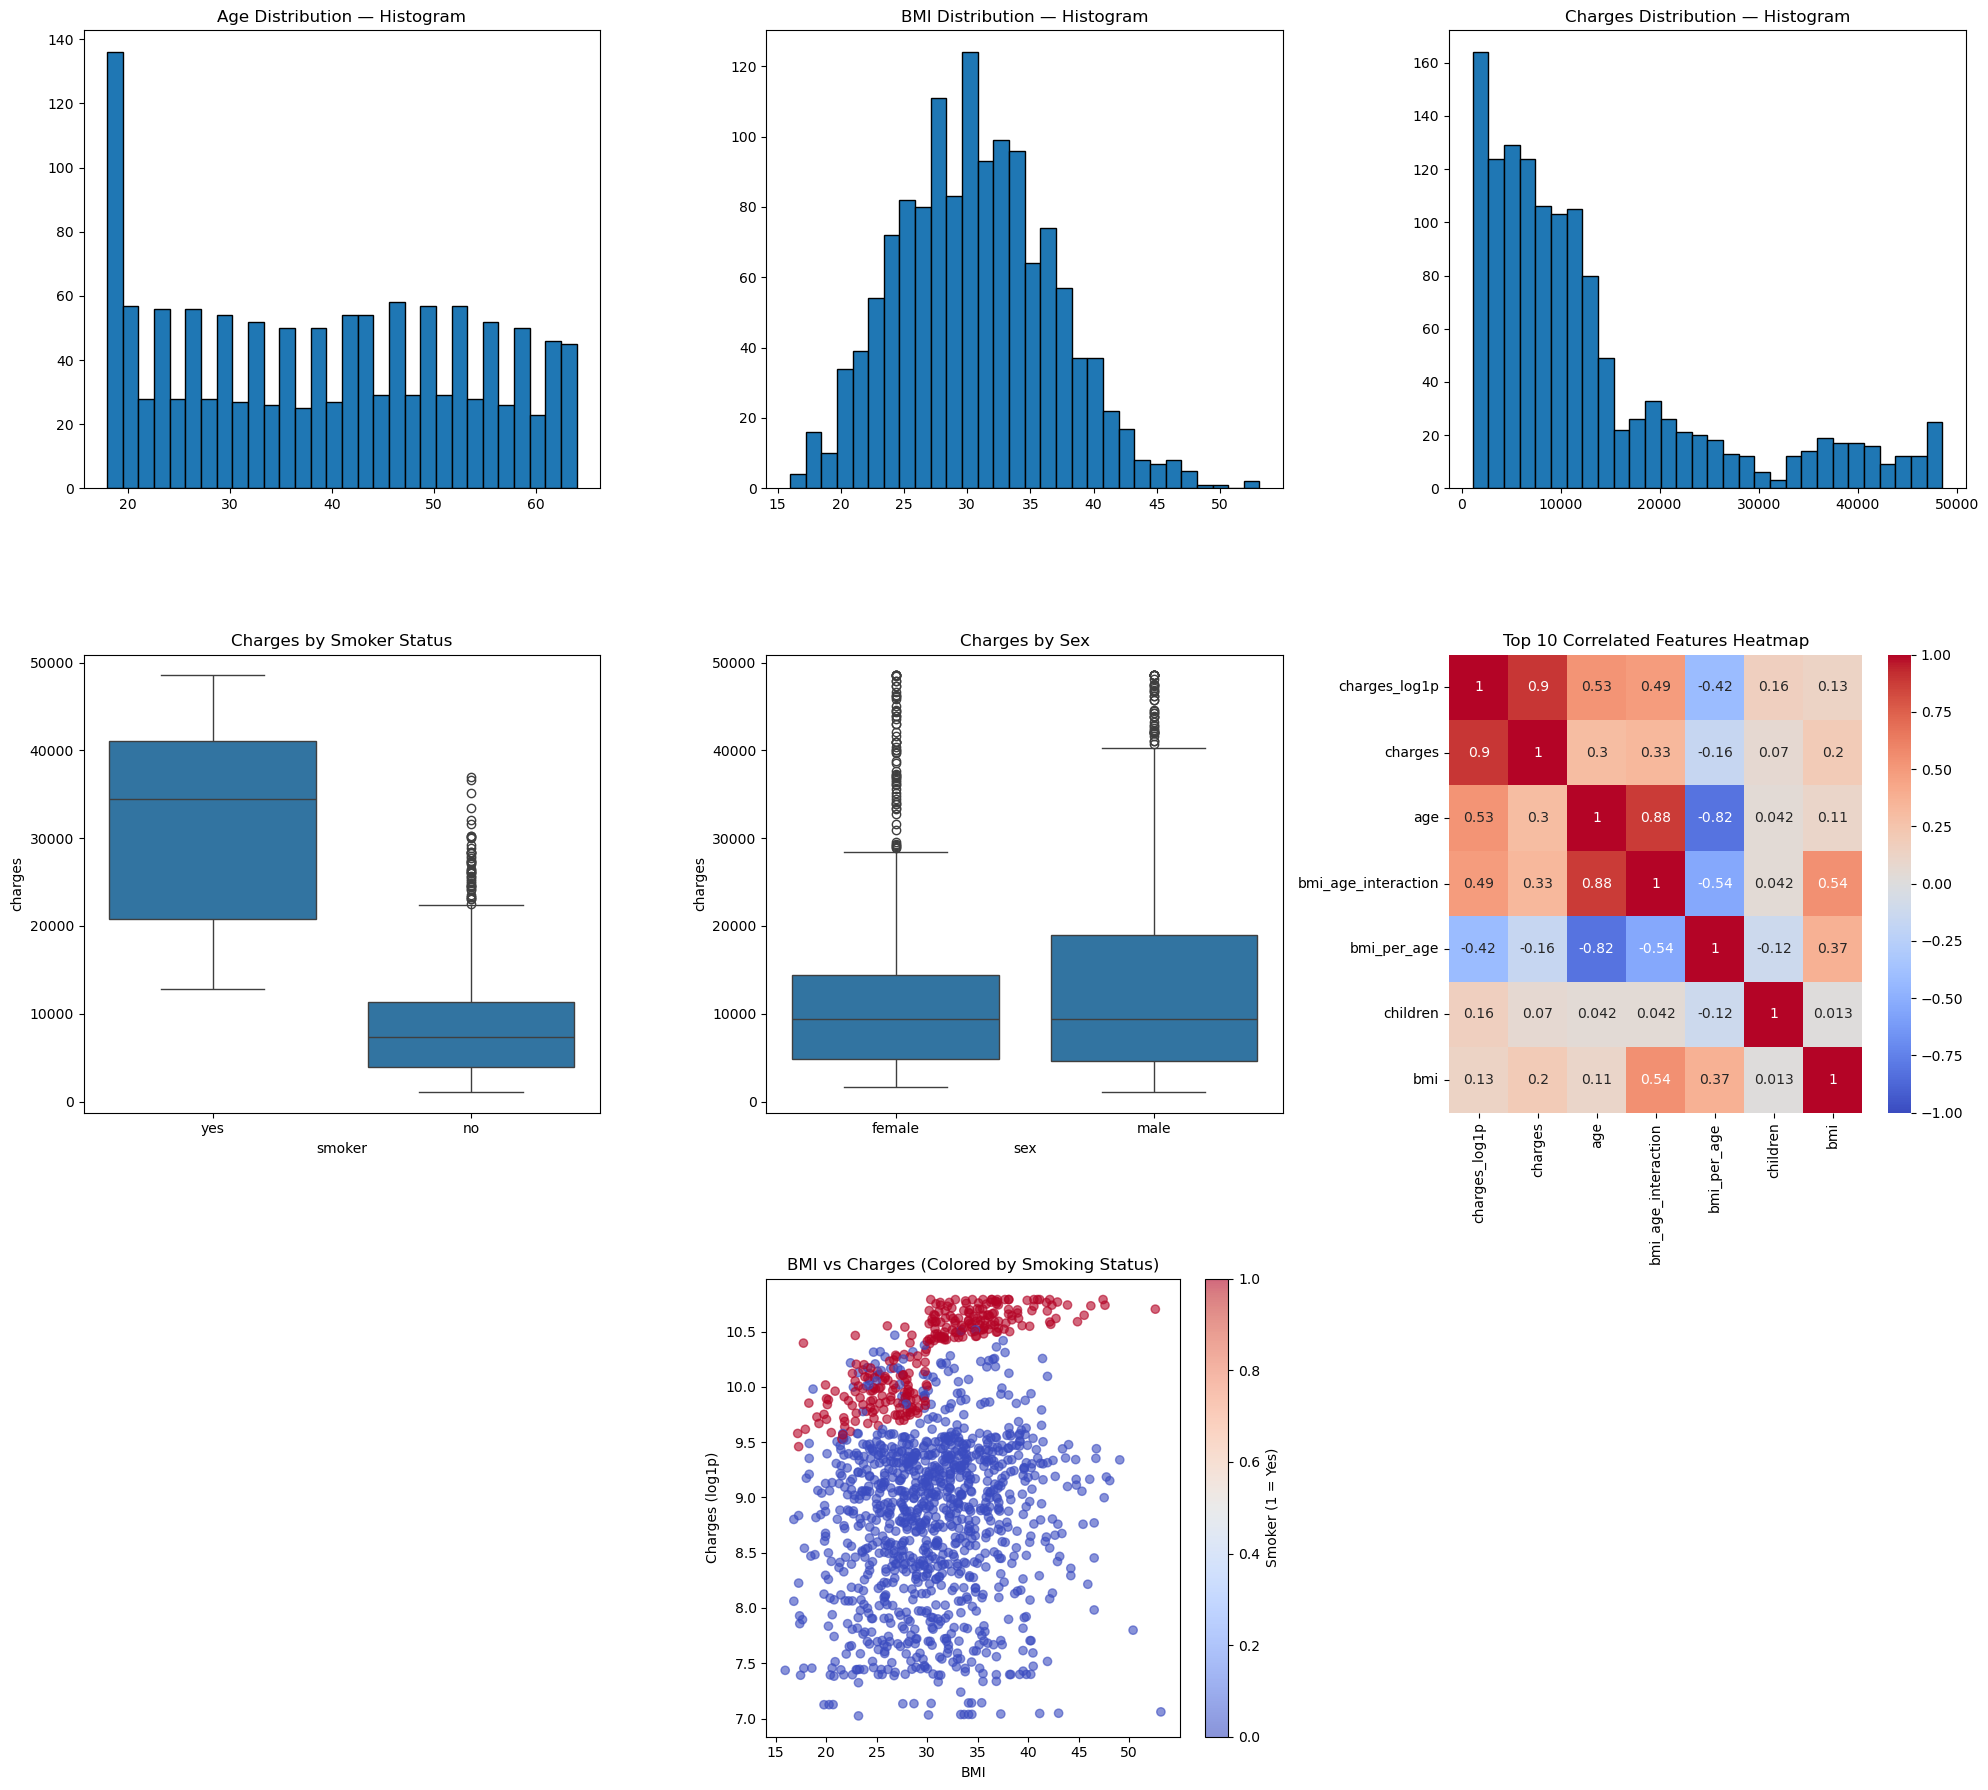

In [89]:
'''
Bonus Opportunities :
• Create a simple dashboard using Matplotlib subplots showing 4+ charts on one figure (+2)
'''
fig, axes = plt.subplots(3, 3, figsize=(20, 18))

axes[0, 0].hist(df_cleaned["age"], bins=30, edgecolor="black")
axes[0, 0].set_title("Age Distribution — Histogram")

axes[0, 1].hist(df_cleaned["bmi"], bins=30, edgecolor="black")
axes[0, 1].set_title("BMI Distribution — Histogram")

axes[0, 2].hist(df_cleaned["charges"], bins=30, edgecolor="black")
axes[0, 2].set_title("Charges Distribution — Histogram")

sns.boxplot(data=df_cleaned, x="smoker", y="charges", ax=axes[1, 0])
axes[1, 0].set_title("Charges by Smoker Status")

sns.boxplot(data=df_cleaned, x="sex", y="charges", ax=axes[1, 1])
axes[1, 1].set_title("Charges by Sex")

sns.heatmap(df_corr[top10].corr(), annot=True, cmap="coolwarm",
            vmin=-1, vmax=1, ax=axes[1, 2])
axes[1, 2].set_title("Top 10 Correlated Features Heatmap")

scatter = axes[2, 1].scatter(
    df_transformed["bmi"],
    df_transformed["charges_log1p"],
    c=df_transformed["smoker_yes"],
    cmap="coolwarm",
    alpha=0.6
)
axes[2, 1].set_title("BMI vs Charges (Colored by Smoking Status)")
axes[2, 1].set_xlabel("BMI")
axes[2, 1].set_ylabel("Charges (log1p)")
plt.colorbar(scatter, ax=axes[2, 1], label="Smoker (1 = Yes)")

axes[2, 0].axis("off")
axes[2, 2].axis("off")

plt.tight_layout()
plt.show()
# a few layout ideas inspired by Microsoft Copilot.


In [95]:
import pickle

with open(r"C:\Users\PC\Desktop\artificial intelligence course 2\STUDENT CAPSTONE PROJECT\df_cleaned.pkl", "wb") as f:
    pickle.dump(df_cleaned, f)

with open(r"C:\Users\PC\Desktop\artificial intelligence course 2\STUDENT CAPSTONE PROJECT\df_transformed.pkl", "wb") as f:
    pickle.dump(df_transformed, f)


In [96]:


with open(r"C:\Users\PC\Desktop\artificial intelligence course 2\STUDENT CAPSTONE PROJECT\df_transformed.pkl", "rb") as f:
    df_transformed_loaded = pickle.load(f)

In [99]:
df_transformed_loaded


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_age_interaction,bmi_per_age,charges_log1p,age_bins_width
0,19,27.900,0,16884.92400,False,True,False,False,True,530.100,1.468421,9.734236,Young
1,18,33.770,1,1725.55230,True,False,False,True,False,607.860,1.876111,7.453882,Young
2,28,33.000,3,4449.46200,True,False,False,True,False,924.000,1.178571,8.400763,Young
3,33,22.705,0,21984.47061,True,False,True,False,False,749.265,0.688030,9.998137,Middle
4,32,28.880,0,3866.85520,True,False,True,False,False,924.160,0.902500,8.260455,Middle
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False,1548.500,0.619400,9.268755,Senior
1334,18,31.920,0,2205.98080,False,False,False,False,False,574.560,1.773333,7.699381,Young
1335,18,36.850,0,1629.83350,False,False,False,True,False,663.300,2.047222,7.396847,Young
1336,21,25.800,0,2007.94500,False,False,False,False,True,541.800,1.228571,7.605365,Young


In [100]:
with open(r"C:\Users\PC\Desktop\artificial intelligence course 2\STUDENT CAPSTONE PROJECT\df_cleaned.pkl", "rb") as f:
    df_cleaned_loaded = pickle.load(f)

df_cleaned_loaded


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
